# LAB 2 - MÉTODOS NUMÉRICOS - ANTÔNIO VINÍCIUS LIBERATO OLIVEIRA SIEBRA - 610619

Importação das bibliotecas numéricas e de visualização padrão do Python (NumPy, pandas e matplotlib), do pacote `statsmodels`, utilizado para construir e ajustar os modelos de regressão linear, das funções estatísticas específicas para calcular o Fator de Inflação da Variância (VIF) e para realizar a Análise de Variância (ANOVA) e das funções auxiliares contidas na biblioteca do livro (`ISLP`), facilitando a carga de dados, criação de matrizes de modelo e exibição de resumos estatísticos.

In [4]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [5]:
import statsmodels.api as sm

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [7]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

Lista os objetos, módulos e funções que estão disponíveis no namespace de nível superior.

In [8]:
dir()

['In',
 'MS',
 'Out',
 'VIF',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anova_lm',
 'exit',
 'get_ipython',
 'load_data',
 'np',
 'open',
 'pd',
 'poly',
 'quit',
 'sm',
 'subplots',
 'summarize']

Array NumPy e inspeção dos seus métodos e atributos internos.

In [9]:
B = np.array([2,6,14])
dir(B)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '_

Método `sum()` no array para somar seus valores.

In [10]:
B.sum()

np.int64(22)

Carrega o dataset "dataset_regressao_limpo" e exibe os nomes de suas colunas.

In [16]:
df_solar_generation = pd.read_csv("dataset_regressao_limpo.csv")
df_solar_generation.columns

Index(['AMBIENT_TEMPERATURE', ' MODULE_TEMPERATURE', ' IRRADIATION           ',
       ' DC_POWER'],
      dtype='object')

In [18]:
# Remove os espaços em branco do começo e do fim de todos os nomes de colunas
df_solar_generation.columns = df_solar_generation.columns.str.strip()


Constrói manualmente uma matriz de modelo (design matrix), definindo uma coluna para o intercepto e uma para a variável preditora `IRRADIATION`.

In [20]:
X = pd.DataFrame({'intercept': np.ones(df_solar_generation.shape[0]),
                  'IRRADIATION': df_solar_generation['IRRADIATION']})
X[:4]


,intercept,IRRADIATION
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0


Separa a variável de resposta `y` (DC_POWER), inicializa o modelo de Mínimos Quadrados Ordinários (OLS) e realiza o ajuste aos dados.

In [22]:
y = df_solar_generation['DC_POWER']
model = sm.OLS(y, X)
results = model.fit()

Aplica a função `summarize` para gerar uma tabela formatada com coeficientes, erros padrão, estatística t e valor-p.

In [23]:
summarize(results)

,coef,std err,t,P>|t|
intercept,74.6641,2.821,26.465,0.0
IRRADIATION,13230.0000,7.406,1785.983,0.0


Construção da matriz do modelo em duas etapas (`fit` e `transform`), utilizando o `ModelSpec`.

In [24]:
design = MS(['IRRADIATION'])
design = design.fit(df_solar_generation)
X = design.transform(df_solar_generation)
X[:4]

,intercept,IRRADIATION
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0


Método `fit_transform` para encurtar o código, executando ajuste e transformação em um único passo.

In [25]:
design = MS(['IRRADIATION'])
X = design.fit_transform(df_solar_generation)
X[:4]

,intercept,IRRADIATION
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0


Relatório analítico completo do modelo ajustado gerado pelo statsmodels.

In [26]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               DC_POWER   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 3.190e+06
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:15:38   Log-Likelihood:            -5.3595e+05
No. Observations:               68774   AIC:                         1.072e+06
Df Residuals:                   68772   BIC:                         1.072e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept      74.6641      2.821     26.465      0.000      69.134      80.194
IRRADIATION  1.323e+04      7.406   1785.983      0.000    1.32e+04    1.32e+04
==============================================================================
Omnibus:                    87234.771   Durbin-Watson:                   1.323
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         54725711.788
Skew:                          -6.507   Prob(JB):                         0.00
Kurtosis:                     140.580   Cond. No.                         3.51
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Extrai isoladamente os coeficientes finais calculados pelo modelo.

In [27]:
results.params

intercept         74.664092
IRRADIATION    13226.202181
dtype: float64

Cria um DataFrame com novos valores para `IRRADIATION` e os converte em matriz de modelo apta para predições.

In [28]:
new_df = pd.DataFrame({'IRRADIATION':[10, 16, 23]})
newX = design.transform(new_df)
newX

,intercept,IRRADIATION
0,1.0,10
1,1.0,16
2,1.0,23


Valores médios preditos da variável resposta (IRRADIATION) para as novas amostras.

In [29]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([132336.68590581, 211693.89899404, 304277.31426364])

Calcula as estimativas do intervalo de confiança de 95% para os valores previstos.

In [30]:
new_predictions.conf_int(alpha=0.05)

array([[132194.84122594, 132478.53058567],
       [211464.9907771 , 211922.80721097],
       [303946.81476068, 304607.8137666 ]])

Calcula as estimativas do intervalo de predição de 95%, incorporando incertezas do erro irredutível.

In [31]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[131178.61163375, 133494.76017787],
       [210521.97106188, 212865.8269262 ],
       [303081.38532434, 305473.24320294]])

Definição básica de uma função customizada `abline` para traçar uma reta.

In [32]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)

Aprimoramento da função `abline` permitindo argumentos adicionais de formatação geométrica (*args, **kwargs).

In [33]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

gráfico de dispersão combinando `IRRADIATION` e `DC_POWER` e sobrepõe a reta de regressão ajustada em vermelho tracejado.

/tmp/ipykernel_1884/513158428.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],
/tmp/ipykernel_1884/513158428.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],


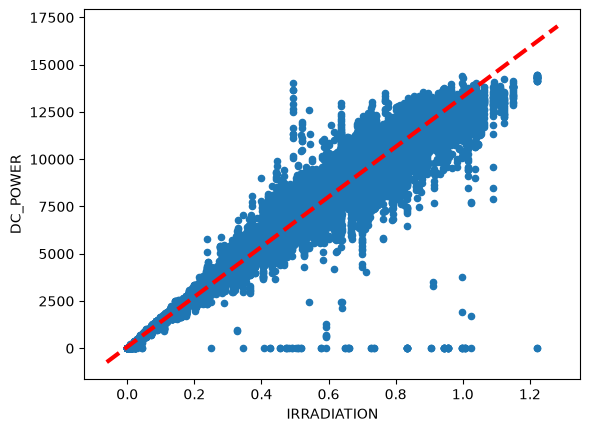

In [34]:
ax = df_solar_generation.plot.scatter('IRRADIATION', 'DC_POWER')
abline(ax,
       results.params[0],
       results.params[1],
       'r--',
       linewidth=3)

Gráfico de resíduos (valores ajustados vs. resíduos) cruzado por uma linha tracejada no zero.

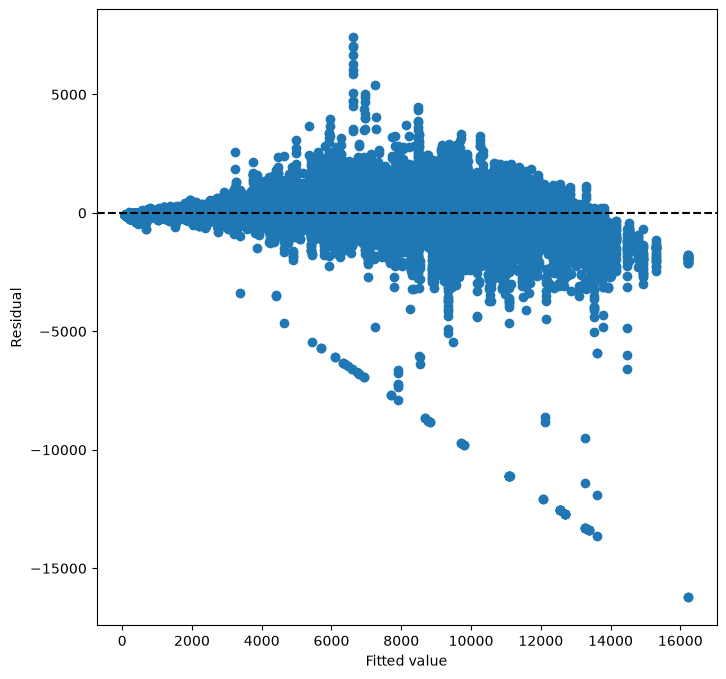

In [35]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

Calcula, plota e identifica o índice da observação de maior alavancagem (leverage) usando a "hat matrix".

np.int64(61602)

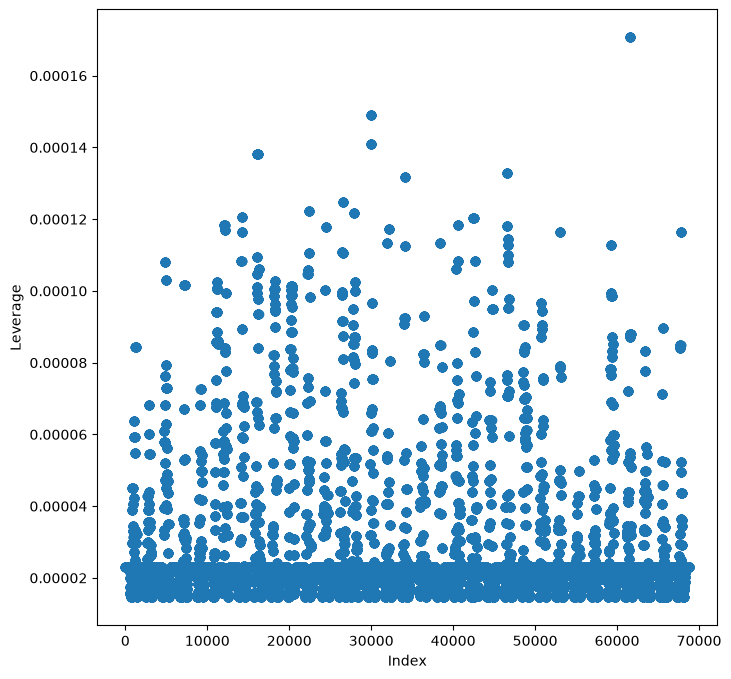

In [36]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

Realiza uma regressão linear múltipla inicial, adicionando a variável `AMBIENT_TEMPERATURE` ao modelo.

In [37]:
X = MS(['IRRADIATION', 'AMBIENT_TEMPERATURE']).fit_transform(df_solar_generation)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,-350.4099,23.000,-15.235,0.0
IRRADIATION,13080.0000,10.730,1219.152,0.0
AMBIENT_TEMPERATURE,17.9485,0.964,18.621,0.0


Cria uma lista com todas as colunas exceto a resposta (DC_POWER) para o modelo amplo.

In [38]:
terms = df_solar_generation.columns.drop('DC_POWER')
terms

Index(['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], dtype='object')

Ajusta modelo de regressão múltipla incorporando todas as variáveis simultaneamente.

In [39]:
X = MS(terms).fit_transform(df_solar_generation)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-239.3749,24.364,-9.825,0.000
AMBIENT_TEMPERATURE,-2.0517,1.752,-1.171,0.242
MODULE_TEMPERATURE,16.3789,1.199,13.663,0.000
IRRADIATION,12600.0000,36.764,342.750,0.000


Exclui o preditor `MODULE_TEMPERATURE` e reajusta um novo modelo com o restante.

In [40]:
minus_age = df_solar_generation.columns.drop(['IRRADIATION', 'AMBIENT_TEMPERATURE'])
Xma = MS(minus_age).fit_transform(df_solar_generation)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,1.408000e-10,7.340000e-13,1.917190e+02,0.0
MODULE_TEMPERATURE,-5.215000e-12,3.250000e-14,-1.602380e+02,0.0
DC_POWER,1.000000e+00,9.920000e-17,1.010000e+16,0.0


Calcula o Fator de Inflação da Variância (VIF) de forma ágil usando compressão de lista (list comprehension).

In [41]:
vals = [VIF(X, i)
        for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
                   index=X.columns[1:])
vif

,vif
AMBIENT_TEMPERATURE,6.989571
MODULE_TEMPERATURE,43.881010
IRRADIATION,24.835686


Alternativa de sintaxe calculando o VIF através de um loop for convencional.

In [42]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))

Inclui interação iterativa (multiplicação) formatada como tupla

In [44]:
X = MS(['IRRADIATION',
        'AMBIENT_TEMPERATURE',
        ('IRRADIATION', 'AMBIENT_TEMPERATURE')]).fit_transform(df_solar_generation)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,-1150.8406,26.886,-42.805,0.0
IRRADIATION,17510.0000,81.978,213.617,0.0
AMBIENT_TEMPERATURE,50.5710,1.118,45.251,0.0
IRRADIATION:AMBIENT_TEMPERATURE,-159.2323,2.922,-54.497,0.0


Aplica a função `poly()` para elevar `IRRADIATION` a uma expansão polinomial quadrática (grau 2).

In [46]:
X = MS([poly('IRRADIATION', degree=2), 'AMBIENT_TEMPERATURE']).fit_transform(df_solar_generation)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,3.264752e+03,23.901,136.595,0.0
"poly(IRRADIATION, degree=2)[0]",1.050000e+06,809.231,1297.840,0.0
"poly(IRRADIATION, degree=2)[1]",-5.546000e+04,565.335,-98.107,0.0
AMBIENT_TEMPERATURE,-4.600200e+00,0.932,-4.938,0.0


Emprega ANOVA testando as hipóteses para comparar o ajuste de qualidade entre modelo linear base e polinomial.

In [47]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,68771.0,2.353011e+10,0.0,NaN,NaN,NaN
1,68770.0,2.064120e+10,1.0,2.888908e+09,9624.933679,0.0


Gráfico de resíduos novamente, mas aplicado ao modelo quadrático ajustado.

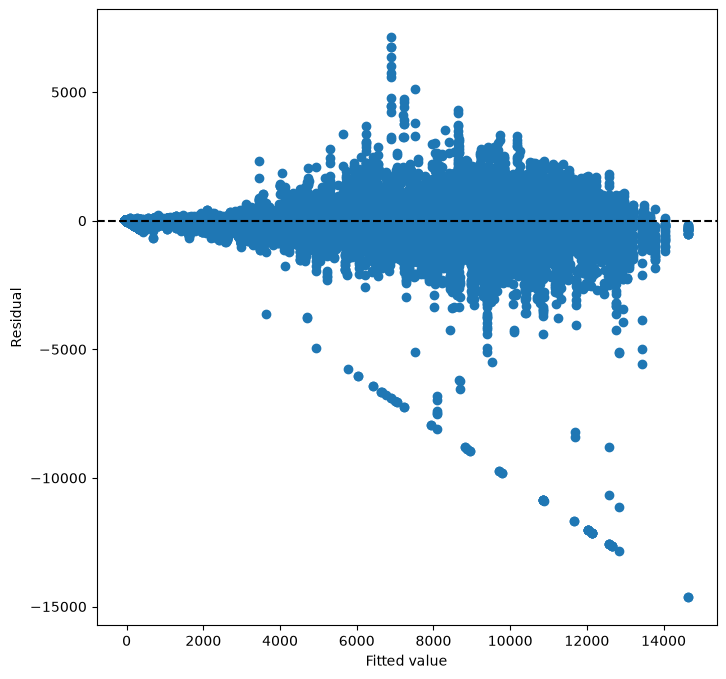

In [48]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues , results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')